# Creating spectroscopic look-up tables

ArchNEMESIS includes functionality to create line-by-line or correlated-k look-up tables compatible with both archNEMESIS and NEMESIS. These programs are based on the spectroscopic calculations made with the LineData class, so we also encourage the users to also explore this [tutorial](https://archnemesis.readthedocs.io/en/latest/examples/linedata/linedata.html) to better understand how the calculations are performed. 

In this notebook, we provide some examples showing how archNEMESIS can be used to create these look-up tables.

In [1]:
import archnemesis as ans
import matplotlib.pyplot as plt
import numpy as np
from archnemesis.Data.path_data import archnemesis_path

## 1. Creating a line-by-line look-up table

We are going to create a look-up table for the main isotope of CO (ID=5, ISO=1) using spectroscopic line data from HITRAN2024, together with the partition sums from TIPS2025.

The main function for creating these look-up tables is called *calc_lbltable()* and is stored in the Spectroscopy_0.py file. A description of the input parameters is defined below:

In [2]:
help(ans.calc_lbltable)

Help on function calc_lbltable in module archnemesis.Spectroscopy_0:

calc_lbltable(outname, gasID, isoID, npress, p0, pn, ntemp, t0, tn, ispace, nwave, wavemin, delwave, iproc, wn_calc_window, wn_approx_window, self_frac, line_database, pf_database='/home/alday/Documents/Projects/archnemesis-dist/archnemesis/Data/partition_functions/tips2025.h5', cont_database=None, include_pressure_shift=True, n_chunks=1, n_cores=1)
    Calculate a line-by-line look-up table for a given gas
    at specified pressure and temperature levels
    
    Input parameters
    -----------------
    @param gasID: int
        Nemesis gas identifier
    @param isoID: int
        Nemesis isotopologue identifier
    @param npress: int
        Number of pressure levels
    @param p0: float
        Minimum pressure level (atm)
    @param pn: float
        Maximum pressure level (atm)
    @param ntemp: int
        Number of temperature levels
    @param t0: float
        Minimum temperature level (K)
    @param tn: f

The calculations of the line-by-line cross sections include some flags that may be turned on or off for optimisation of the calculations. 

The parameter *n_chunks* defines the number of chunks into which the spectral range is divided to perform the calculations, which may or not be calculated in parallel. In some occassions, if the spectral range we are defining for the calculations is too wide, the arrays may become too large and may require a lot of memory. Splitting the calculations into smaller chunks alleviates this requirement.

In some cases, it may be desirable to split the spectral range into *n_chunks*, but then perform the calculation of each chunk in parallel, to speed up the calculations. This is defined by the parameter *n_cores*, which defines the number of parallel processes that may be performed. The parameter *n_cores* must therefore be between 1 and *n_chunks*.

In [5]:
#lbl-table inputs
################################################################################

#CO
gasID = 5 ; isoID = 1
outname = "example_co"
 
npress = 2 ; p0 = 1.0e-6 ; pn = 1.0e-2
ntemp = 2 ; t0 = 130. ; tn = 250.

ispace = 0   #wavenumber (cm-1)
vmin = 1900. ; delv = 0.001 ; nwave = 500001

iproc = 0             #Voigt lineshape
wn_calc_window = 25.  #Caclculation window (cm-1)
wn_approx_window = 250.  #Caclculation window (cm-1)
self_frac = 0.5       #fraction of self-broadening

line_base = archnemesis_path()+"/tests/files/linedata/CO_1_ambient_AIR.h5"
pf_base = archnemesis_path()+'/archnemesis/Data/partition_functions/tips2025.h5'
 
#Performing calculations
###################################################################################

#Calculating lbl-table
ans.calc_lbltable(outname,                       #Name of the output .lta file
                  gasID,isoID,                   #Gas information
                  npress,p0,pn,                  #Pressure grid
                  ntemp,t0,tn,                   #Temperature grid
                  ispace,nwave,vmin,delv,        #Wavenumber grid
                  iproc,                         #Lineshape identifier
                  wn_calc_window,                #Wavenumber calculation window (cm-1)
                  wn_approx_window,              #Wavenumber window at which an approximation for the wings is applied (cm-1)
                  self_frac,                     #Self-broadening fraction
                  line_base,                     #Database
                  pf_database=pf_base,           #Partition function database (default = TIPS2025)
                  cont_database=None,            #Pseudo-continuum database (If not None, it will use the same as the line_database)
                  include_pressure_shift=True,   #Flag to include pressure shift in the waveumbers
                  n_chunks = 2,
                  n_cores = 1,
)

INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1472 :: RUNTIME calculation is loading desired wavenumber range from databases
INFO :: read_tables :: Spectroscopy_0.py-1478 :: Reading table self.LOCATION_LD[igas]='/home/alday/Documents/Projects/archnemesis-dist/tests/files/linedata/CO_1_ambient_AIR.h5' wavemin=1900.0 wavemax=2400.0
INFO :: calc_lbltable_chunk :: Spectroscopy_0.py-3312 :: Calculating absorption cross-sections for wavenumber range 1900.00 - 2150.00 cm-1
INFO :: calc_lbltable_chunk :: Spectroscopy_0.py-3316 :: (1/2) Pressure level 1.00e-06 atm
INFO :: calc_klbl_online :: Spectroscopy_0.py-2111 :: Gas 5, Isotope 1 - Calculating line-by-line cross sections at runtime...
INFO :: calc_lbltable_chunk :: Spectroscopy_0.py-3316 :: (2/2) Pressure level 1.00e-02 atm
INFO :: calc_klbl_online :: Spectroscopy_0.py-2111 :: Gas 5, Isotope 1 - Calculating line-by-line cross sections at runtime...
INFO :: calc_lbltable_chunk :: Spe

In [6]:
#Reading the table
#Initialising spectroscopy class with ILBL = 2 (line-by-line)
Spectroscopy = ans.Spectroscopy_0(ILBL=2)

Spectroscopy.NGAS = 1  #We define two gases in the class
Spectroscopy.LOCATION = [outname+'.lta']

#Reading the header information
Spectroscopy.read_header()

#Printing summary information
Spectroscopy.summary_info()

INFO :: summary_info :: Spectroscopy_0.py-459 :: 
#===== SUMMARY =====#
	Spectroscopy_0 instance at memory location 138099509459600
	Calculation type ILBL ::  (<SpectralCalculationModeEnum.LINE_BY_LINE_TABLES: 2>, ' (line-by-line)')
	Number of radiatively-active gaseous species ::  1
	Gaseous species ::  ['CO (1)']
	Number of spectral points ::  500001
	Wavelength range ::  (np.float64(1900.0), '-', np.float64(2400.0))
	Step size ::  0.0009999999999763531
	Number of temperature levels ::  2
	Temperature range ::  (np.float32(130.0), '-', np.float32(250.0))
	Number of pressure levels ::  2
	Pressure range ::  (np.float32(1e-06), '-', np.float32(0.01))
#===================#


INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1522 :: Reading table self.LOCATION[igas]='example_co.lta' wavemin=0.0 wavemax=10000000000.0


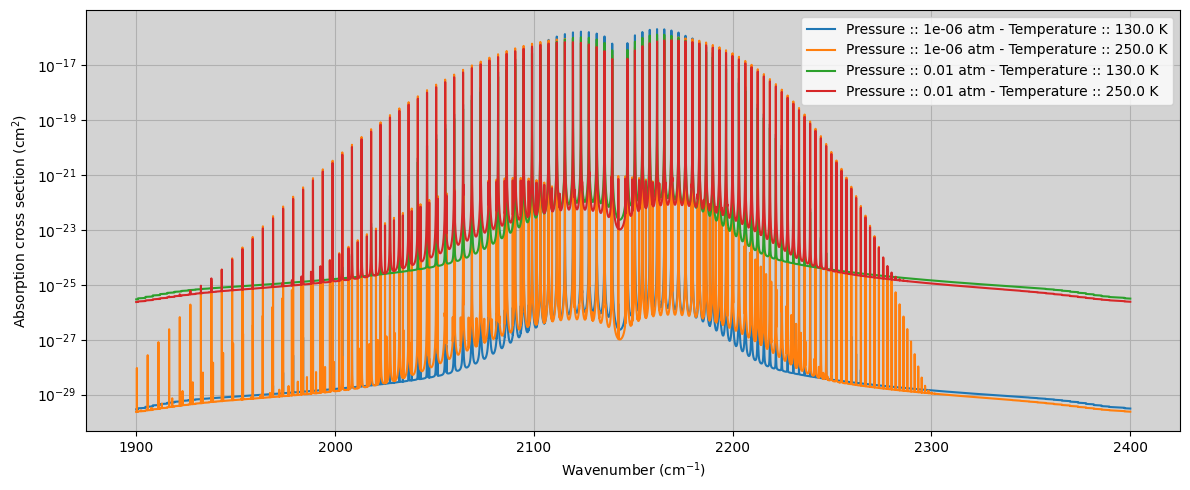

In [7]:
#Reading the information in the lbl-tables in a specified spectral range
Spectroscopy.read_tables()

fig,(ax) = plt.subplots(Spectroscopy.NGAS,1,figsize=(12,5),sharex=True)


ipress = 0 ; itemp = 0
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = 0 ; itemp = -1
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = -1 ; itemp = 0
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = -1 ; itemp = -1
ax.plot(Spectroscopy.WAVE,Spectroscopy.K[:,ipress,itemp,0],label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')



ax.set_yscale('log')
ax.set_ylabel('Absorption cross section (cm$^2$)')
ax.legend()
ax.grid()
ax.set_facecolor('lightgray')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
plt.tight_layout()


## 2. Creating a correlated-k look-up table

Now, we are going to perform a similar exercise, but instead of creating a line-by-line look-up table, we are going to create a correlated-k look-up table storing the k-coefficients. Specifically, we are going to create a look-up table for an instrument with an instrument lineshape described by a Gaussian function with a FWHM of 5 cm$^{-1}$. The spectral sampling will be set to 1 cm$^{-1}$.



The main function for creating these look-up tables is called calc_ktable() and is stored in the Spectroscopy_0.py file. A description of the input parameters is defined below:

In [8]:
help(ans.calc_ktable)

Help on function calc_ktable in module archnemesis.Spectroscopy_0:

calc_ktable(outname, gasID, isoID, npress, p0, pn, ntemp, t0, tn, ispace, nwave, wavemin, delwave, ng, iproc, wn_calc_window, wn_approx_window, self_frac, line_database, pf_database='/home/alday/Documents/Projects/archnemesis-dist/archnemesis/Data/partition_functions/tips2025.h5', cont_database=None, Measurement=None, include_pressure_shift=True, n_cores=1, n_chunks=1, delv_lbl=0.0001)
    Calculate a correlated-k look-up table for a given gas
    at specified pressure and temperature levels
    
    Input parameters
    -----------------
    @param gasID: int
        Nemesis gas identifier
    @param isoID: int
        Nemesis isotopologue identifier
    @param npress: int
        Number of pressure levels
    @param p0: float
        Minimum pressure level (atm)
    @param pn: float
        Maximum pressure level (atm)
    @param ntemp: int
        Number of temperature levels
    @param t0: float
        Minimum tem

Similar to the lbl-calculations, here we can also define the parameters *n_chunks* and *n_cores*, and it can have a big impact on the performance of the calculations.

For calculating the k-coefficients in a given bin, we first need to calculate the high-spectral resolution absorption cross sections (i.e., line-by-line calculations) within the bin, which are later transformed into the k-coefficients. Generally, the window for calculating the line-by-line cross sections is much wider that the size of the bin (e.g., in our example the k-tables require a FWHM = 5 cm$^{-1}$ compared to the 25-250 cm$^{-1}$ window for the line-by-line calculations. Therefore, the absorption coefficients for two adjacent bins are very similar (i.e., a lot of the spectral range is shared for the two bins) and it is best to calculate it at the same time. From this perspective, the most efficient calculations are performed when *n_chunks* = 1. However, when the spectral range becomes wider, it may be more efficient to divide the spectral range into several chunks and then calculate them in parallel.

Before creating k-tables, we recommend the user to make some tests to find the optimal performance for their desired inputs.

In [9]:
#k-table inputs
################################################################################

#CO
gasID = 5 ; isoID = 1
outname = "example_co"
 
npress = 2 ; p0 = 1.0e-6 ; pn = 1.0e-2
ntemp = 2 ; t0 = 130. ; tn = 250.

#Spectral grid and k-coefficient calculations
ispace = 0   #wavenumber (cm-1)
vmin = 1900. ; delv = 1. ; nwave = 501
ng = 20

#Spectroscopic calculations
iproc = 0             #Voigt lineshape
wn_calc_window = 25.  #Caclculation window (cm-1)
wn_approx_window = 250.  #Caclculation window (cm-1)
self_frac = 0.5       #fraction of self-broadening

line_base = archnemesis_path()+"/tests/files/linedata/CO_1_ambient_AIR.h5"
#line_base = "/srv/workspace/data/nemesis/spectroscopy/linedata/hitran24/hitran24.h5"
pf_base = archnemesis_path()+'/archnemesis/Data/partition_functions/tips2025.h5'

#Defining the instrument lineshape (Gaussian function with FWHM = 5 cm-1)
fwhm = 5.
if fwhm != 0.0:
    Measurement=ans.Measurement_0()
    Measurement.FWHM = fwhm        #FWHM  = 5 cm-1
    Measurement.ISPACE = ispace    #Wavenumber space
    Measurement.ISHAPE = 2         #Gaussian function for the ILS
    Measurement.NGEOM = 1
    vmaxx = vmin + delv * (nwave - 1)
    vwave = np.linspace( vmin , vmaxx , nwave )
    vconv = np.zeros((len(vwave),1))
    vconv[:,0] = vwave
    Measurement.NCONV = np.zeros(1,dtype="int32") + len(vwave)
    Measurement.edit_VCONV(vconv)  #Defining the convolution wavenumbers (must be the same as in the k-table)
    Measurement.build_ils()        #Building the ILS 
else: 
    Measurement = None


#Performing calculations
###################################################################################

#Calculating lbl-table
ans.calc_ktable(outname,                       #Name of the output .lta file
                gasID,isoID,                   #Gas information
                npress,p0,pn,                  #Pressure grid
                ntemp,t0,tn,                   #Temperature grid
                ispace,nwave,vmin,delv,        #Wavenumber grid
                ng,                            #Number of g-ordinates
                iproc,                         #Lineshape identifier
                wn_calc_window,                #Wavenumber calculation window (cm-1)
                wn_approx_window,              #Wavenumber window at which an approximation for the wings is applied (cm-1)
                self_frac,                     #Self-broadening fraction
                line_base,                     #Database
                pf_database=pf_base,           #Partition function database (default = TIPS2025)
                cont_database=None,            #Pseudo-continuum database (If not None, it will use the same as the line_database)
                include_pressure_shift=True,   #Flag to include pressure shift in the waveumbers
                Measurement=Measurement,
                n_chunks = 5,
                n_cores = 5,
)

INFO :: calc_ktable_chunk :: Spectroscopy_0.py-3664 :: Selecting lines in the spectral range 1890.99 - 2009.01 for the calculations
INFO :: calc_ktable_chunk :: Spectroscopy_0.py-3664 :: Selecting lines in the spectral range 1991.99 - 2109.01 for the calculations
INFO :: calc_ktable_chunk :: Spectroscopy_0.py-3664 :: Selecting lines in the spectral range 2091.99 - 2209.01 for the calculations
INFO :: calc_ktable_chunk :: Spectroscopy_0.py-3664 :: Selecting lines in the spectral range 2191.99 - 2309.01 for the calculations
INFO :: calc_ktable_chunk :: Spectroscopy_0.py-3664 :: Selecting lines in the spectral range 2291.99 - 2409.01 for the calculations
INFO :: create_from :: LineData_0.py-1063 :: iso_line_data._data.shape=(11, 282)
INFO :: calc_ktable_chunk :: Spectroscopy_0.py-3694 :: Calculating k-coefficients at p = 1.0000000000000004e-06 atm and t = 130.0 K
INFO :: create_from :: LineData_0.py-1063 :: iso_line_data._data.shape=(11, 259)
INFO :: calc_ktable_chunk :: Spectroscopy_0.py

In [10]:
#Reading the table
#Initialising spectroscopy class with ILBL = 2 (line-by-line)
Spectroscopy = ans.Spectroscopy_0(ILBL=0)

Spectroscopy.NGAS = 1  #We define two gases in the class
Spectroscopy.LOCATION = [outname+'.kta']

#Reading the header information
Spectroscopy.read_header()

#Printing summary information
Spectroscopy.summary_info()

INFO :: summary_info :: Spectroscopy_0.py-459 :: 
#===== SUMMARY =====#
	Spectroscopy_0 instance at memory location 138102729030288
	Calculation type ILBL ::  (<SpectralCalculationModeEnum.K_TABLES: 0>, ' (k-distribution)')
	Number of radiatively-active gaseous species ::  1
	Gaseous species ::  ['CO (1)']
	Number of g-ordinates ::  20
	Number of spectral points ::  501
	Wavelength range ::  (np.float64(1900.0), '-', np.float64(2400.0))
	Step size ::  1.0
	Spectral resolution of the k-tables (FWHM) ::  5.0
	Number of temperature levels ::  2
	Temperature range ::  (np.float32(130.0), '-', np.float32(250.0))
	Number of pressure levels ::  2
	Pressure range ::  (np.float32(1e-06), '-', np.float32(0.01))
#===================#


INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1513 :: Reading table self.LOCATION[igas]='example_co.kta' wavemin=0.0 wavemax=10000000000.0


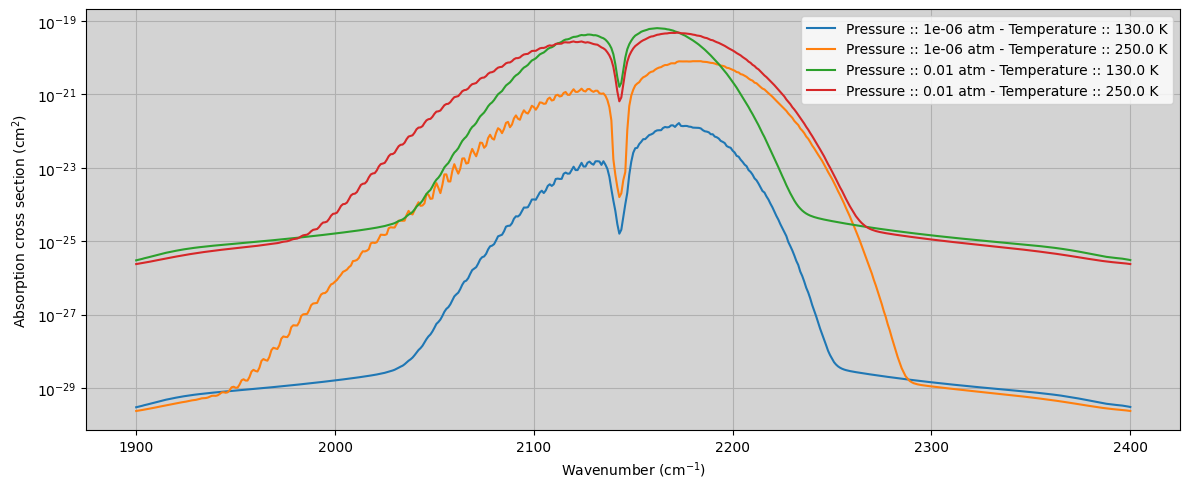

In [11]:
#Reading the information in the lbl-tables in a specified spectral range
Spectroscopy.read_tables()

fig,(ax) = plt.subplots(Spectroscopy.NGAS,1,figsize=(12,5),sharex=True)


ipress = 0 ; itemp = 0
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = 0 ; itemp = -1
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = -1 ; itemp = 0
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')

ipress = -1 ; itemp = -1
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label='Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')


ax.set_yscale('log')
ax.set_ylabel('Absorption cross section (cm$^2$)')
ax.legend()
ax.grid()
ax.set_facecolor('lightgray')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
plt.tight_layout()

## 3. Comparing both look-up tables

In this part, we are just going to show a comparison of the line-by-line and correlated-k look-up tables to see how they look. 

In [12]:
#Reading the table
#Initialising spectroscopy class with ILBL = 2 (line-by-line)
Spectroscopy_LBL = ans.Spectroscopy_0(ILBL=2)

Spectroscopy_LBL.NGAS = 1  #We define two gases in the class
Spectroscopy_LBL.LOCATION = [outname+'.lta']

#Reading the header information
Spectroscopy_LBL.read_header()

#Printing summary information
Spectroscopy_LBL.summary_info()

INFO :: summary_info :: Spectroscopy_0.py-459 :: 
#===== SUMMARY =====#
	Spectroscopy_0 instance at memory location 138099510705936
	Calculation type ILBL ::  (<SpectralCalculationModeEnum.LINE_BY_LINE_TABLES: 2>, ' (line-by-line)')
	Number of radiatively-active gaseous species ::  1
	Gaseous species ::  ['CO (1)']
	Number of spectral points ::  500001
	Wavelength range ::  (np.float64(1900.0), '-', np.float64(2400.0))
	Step size ::  0.0009999999999763531
	Number of temperature levels ::  2
	Temperature range ::  (np.float32(130.0), '-', np.float32(250.0))
	Number of pressure levels ::  2
	Pressure range ::  (np.float32(1e-06), '-', np.float32(0.01))
#===================#


INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1513 :: Reading table self.LOCATION[igas]='example_co.kta' wavemin=0.0 wavemax=10000000000.0
INFO :: read_tables :: Spectroscopy_0.py-1465 :: Reading tables
INFO :: read_tables :: Spectroscopy_0.py-1522 :: Reading table self.LOCATION[igas]='example_co.lta' wavemin=0.0 wavemax=10000000000.0


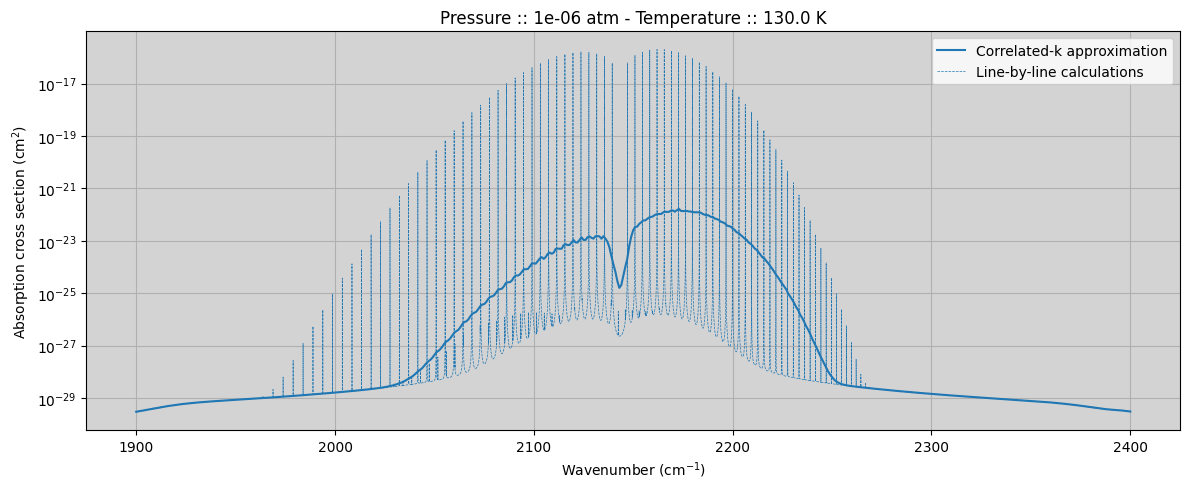

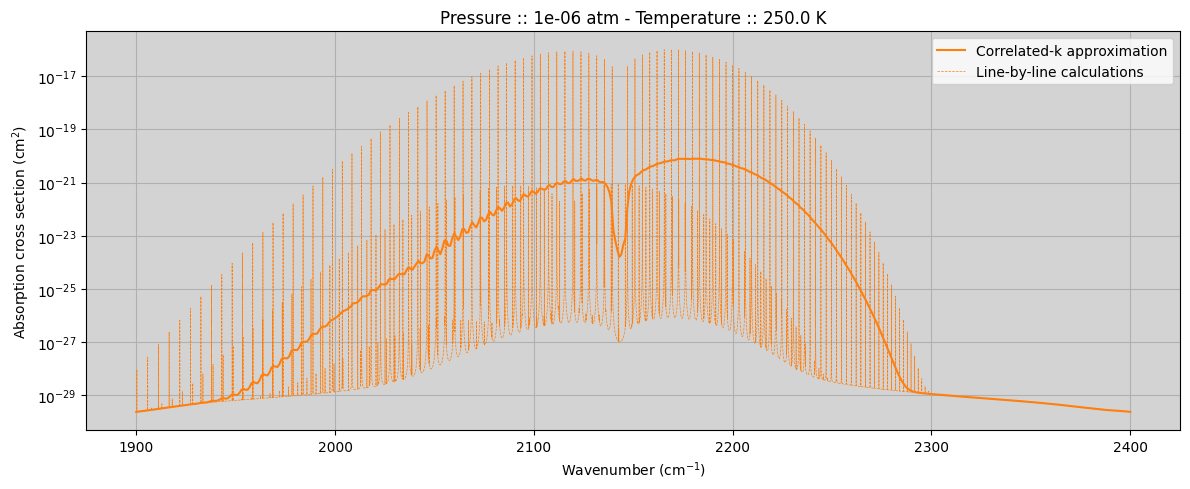

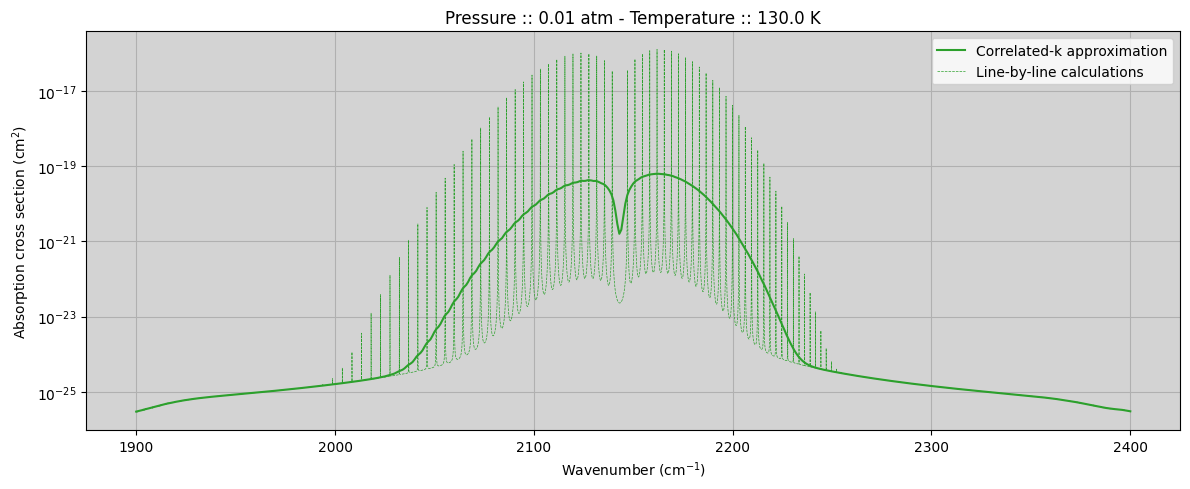

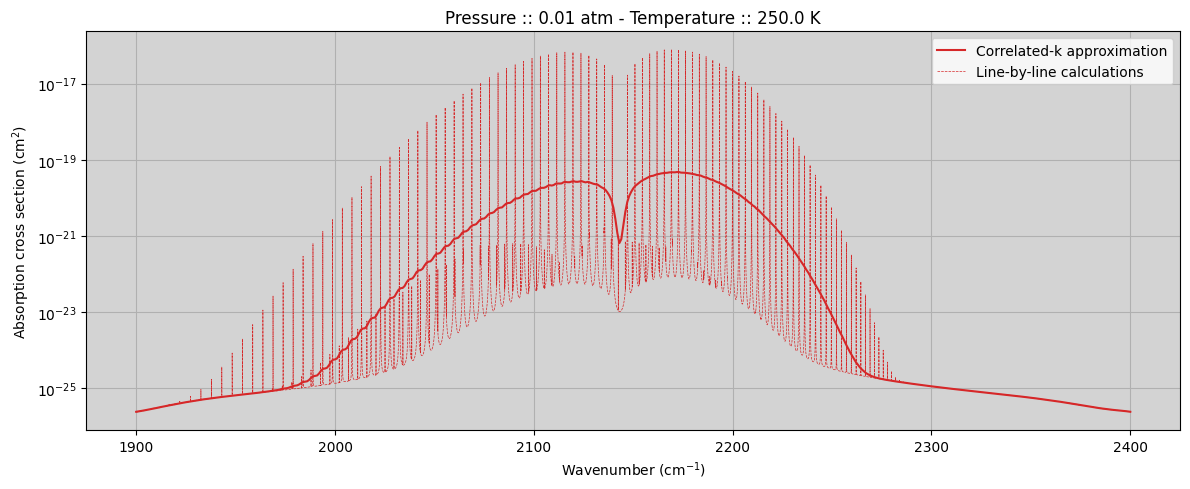

In [13]:
#Reading the information in the lbl-tables in a specified spectral range
Spectroscopy.read_tables()
Spectroscopy_LBL.read_tables()

fig,(ax) = plt.subplots(Spectroscopy.NGAS,1,figsize=(12,5),sharex=True)
c = "tab:blue"
ipress = 0 ; itemp = 0
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label="Correlated-k approximation",c=c)
ax.plot(Spectroscopy_LBL.WAVE,Spectroscopy_LBL.K[:,ipress,itemp,0],linestyle="--",c=c,linewidth=0.5,label="Line-by-line calculations")
ax.set_title('Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')
ax.set_yscale('log')
ax.set_ylabel('Absorption cross section (cm$^2$)')
ax.legend()
ax.grid()
ax.set_facecolor('lightgray')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
plt.tight_layout()


fig,(ax) = plt.subplots(Spectroscopy.NGAS,1,figsize=(12,5),sharex=True)
c = "tab:orange"
ipress = 0 ; itemp = -1
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label="Correlated-k approximation",c=c)
ax.plot(Spectroscopy_LBL.WAVE,Spectroscopy_LBL.K[:,ipress,itemp,0],linestyle="--",c=c,linewidth=0.5,label="Line-by-line calculations")
ax.set_title('Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')
ax.set_yscale('log')
ax.set_ylabel('Absorption cross section (cm$^2$)')
ax.legend()
ax.grid()
ax.set_facecolor('lightgray')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
plt.tight_layout()

fig,(ax) = plt.subplots(Spectroscopy.NGAS,1,figsize=(12,5),sharex=True)
c = "tab:green"
ipress = -1 ; itemp = 0
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label="Correlated-k approximation",c=c)
ax.plot(Spectroscopy_LBL.WAVE,Spectroscopy_LBL.K[:,ipress,itemp,0],linestyle="--",c=c,linewidth=0.5,label="Line-by-line calculations")
ax.set_title('Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')
ax.set_yscale('log')
ax.set_ylabel('Absorption cross section (cm$^2$)')
ax.legend()
ax.grid()
ax.set_facecolor('lightgray')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
plt.tight_layout()

fig,(ax) = plt.subplots(Spectroscopy.NGAS,1,figsize=(12,5),sharex=True)
c = "tab:red"
ipress = -1 ; itemp = -1
k = np.matmul(Spectroscopy.K[:,:,ipress,itemp,0],Spectroscopy.DELG)
ax.plot(Spectroscopy.WAVE,k,label="Correlated-k approximation",c=c)
ax.plot(Spectroscopy_LBL.WAVE,Spectroscopy_LBL.K[:,ipress,itemp,0],linestyle="--",c=c,linewidth=0.5,label="Line-by-line calculations")
ax.set_title('Pressure :: '+str(Spectroscopy.PRESS[ipress])+' atm - Temperature :: '+str(Spectroscopy.TEMP[itemp])+' K')
ax.set_yscale('log')
ax.set_ylabel('Absorption cross section (cm$^2$)')
ax.legend()
ax.grid()
ax.set_facecolor('lightgray')
ax.set_xlabel('Wavenumber (cm$^{-1}$)')
plt.tight_layout()